# Store Sales Prediction for Corporación Favorita

## Introduction
This project focuses on forecasting unit sales for grocery items at Corporación Favorita stores in Ecuador using time-series data. The dataset includes information on store, item details, promotions, and sales, which will be used to build an accurate sales prediction model. The data can be downloaded from the [Kaggle competition page](https://www.kaggle.com/competitions/store-sales-time-series-forecasting/data).


In [2]:
import datetime
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_log_error

In [3]:
train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")
df_holidays = pd.read_csv("holidays_events.csv")
df_oil = pd.read_csv("oil.csv")

In [4]:
train.head()

,id,date,store_nbr,family,sales,onpromotion
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0
1,1,2013-01-01,1,BABY CARE,0.0,0
2,2,2013-01-01,1,BEAUTY,0.0,0
3,3,2013-01-01,1,BEVERAGES,0.0,0
4,4,2013-01-01,1,BOOKS,0.0,0


In [5]:
train.shape

(3000888, 6)

In [6]:
df_holidays.head()

,date,type,locale,locale_name,description,transferred
0,2012-03-02,Holiday,Local,Manta,Fundacion de Manta,False
1,2012-04-01,Holiday,Regional,Cotopaxi,Provincializacion de Cotopaxi,False
2,2012-04-12,Holiday,Local,Cuenca,Fundacion de Cuenca,False
3,2012-04-14,Holiday,Local,Libertad,Cantonizacion de Libertad,False
4,2012-04-21,Holiday,Local,Riobamba,Cantonizacion de Riobamba,False


In [7]:
# for train dataset
train['date_ti'] = pd.to_datetime(train['date'] , errors = 'coerce')

In [8]:
train['date_conv'] = train['date_ti'].dt.strftime("%Y%m%d").astype(int)
train.drop(columns = ['date' , 'date_ti'] , axis = 1 , inplace = True)

In [9]:
y = train['sales']
train.drop(columns = ['sales'] , inplace = True , axis = 1)

In [10]:
# for test dtaset
test['date'] = pd.to_datetime(test['date'] , errors = 'coerce')
test['date_conv'] = test['date'].dt.strftime("%Y%m%d").astype(int)
test.drop('date' , axis = 1 , inplace = True)

In [18]:
data = pd.date_range('2013-01-01', '2017-08-31')
df_calendar = pd.DataFrame(data,columns=['date'])
df_calendar

,date
0,2013-01-01
1,2013-01-02
2,2013-01-03
3,2013-01-04
4,2013-01-05
...,...
1699,2017-08-27
1700,2017-08-28
1701,2017-08-29
1702,2017-08-30


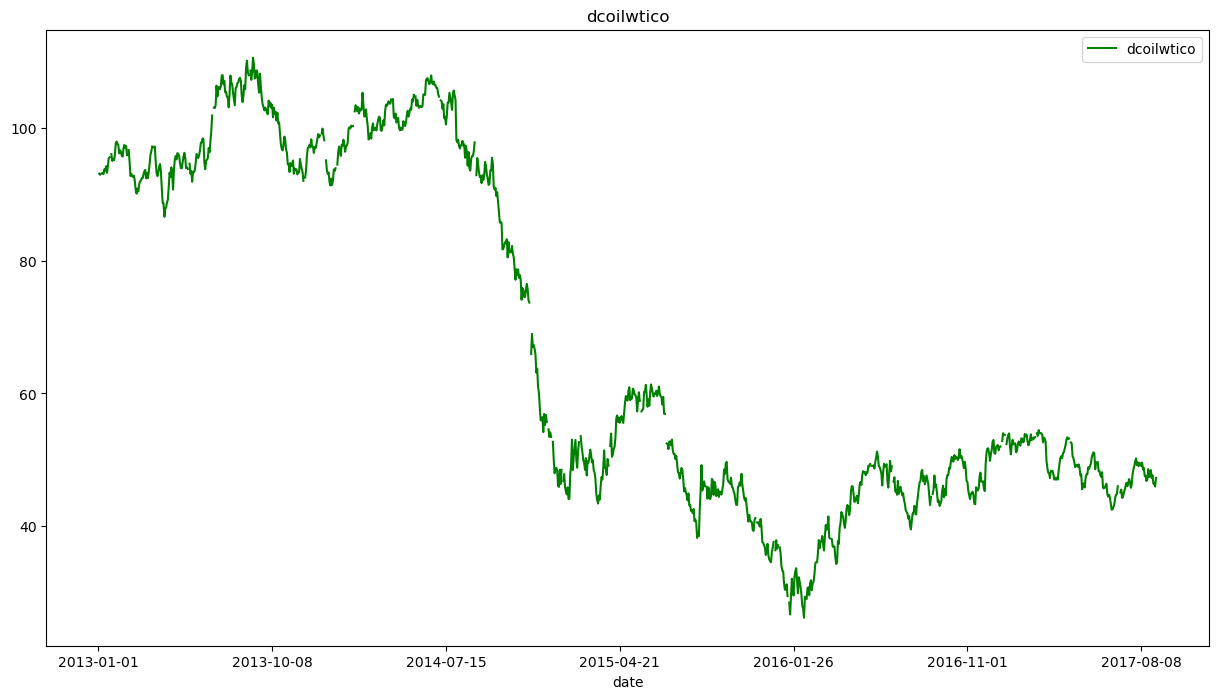

In [23]:
# oil price
fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(15,8))
df_oil.plot.line(x="date", y="dcoilwtico", color='green', title ="dcoilwtico", ax = axes, rot=0)
plt.show()

In [25]:
df_oil['date'] = pd.to_datetime(df_oil['date'] , errors = 'coerce')
df_calendar = pd.merge(df_calendar,df_oil, how='left',on='date')

df_calendar['dcoilwtico'].fillna(method='ffill', inplace=True)

C:\Users\zeyil\AppData\Local\Temp\ipykernel_23908\4150677265.py:4: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_calendar['dcoilwtico'].fillna(method='ffill', inplace=True)


In [27]:
df_oil.isnull().sum()

date           0
dcoilwtico    43
dtype: int64

In [29]:
df_calendar['dcoilwtico'].fillna(method='bfill', inplace=True)

C:\Users\zeyil\AppData\Local\Temp\ipykernel_23908\1288933593.py:1: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_calendar['dcoilwtico'].fillna(method='bfill', inplace=True)


In [31]:
# holidays
df_holidays[(df_holidays['description'].str.contains('Guayaquil'))&(df_holidays['locale']=='National')].head()

,date,type,locale,locale_name,description,transferred
19,2012-10-09,Holiday,National,Ecuador,Independencia de Guayaquil,True
20,2012-10-12,Transfer,National,Ecuador,Traslado Independencia de Guayaquil,False
72,2013-10-09,Holiday,National,Ecuador,Independencia de Guayaquil,True
73,2013-10-11,Transfer,National,Ecuador,Traslado Independencia de Guayaquil,False
135,2014-10-09,Holiday,National,Ecuador,Independencia de Guayaquil,True


In [33]:
df_holidays['date'] = df_holidays['date'].replace({'2013-04-29' : pd.to_datetime('2013-03-29')})

df_holidays = df_holidays[df_holidays.locale == 'National']

In [35]:
df_holidays['date'] = pd.to_datetime(df_holidays['date'] , errors = 'coerce')
df_holidays = df_holidays.drop_duplicates(subset=['date'])

In [37]:
df_calendar['day_week'] = df_calendar['date'].dt.dayofweek

df_calendar['holiday_or_weekday'] = 'weekday'
df_calendar.loc[df_calendar['day_week'] > 4, 'holiday_or_weekday'] = 'holiday'

df_calendar.head()

,date,dcoilwtico,day_week,holiday_or_weekday
0,2013-01-01,93.14,1,weekday
1,2013-01-02,93.14,2,weekday
2,2013-01-03,92.97,3,weekday
3,2013-01-04,93.12,4,weekday
4,2013-01-05,93.12,5,holiday


In [39]:
df_calendar = pd.merge(df_calendar, df_holidays,how='left',on='date')
df_calendar.head()

,date,dcoilwtico,day_week,holiday_or_weekday,type,locale,locale_name,description,transferred
0,2013-01-01,93.14,1,weekday,Holiday,National,Ecuador,Primer dia del ano,False
1,2013-01-02,93.14,2,weekday,NaN,NaN,NaN,NaN,NaN
2,2013-01-03,92.97,3,weekday,NaN,NaN,NaN,NaN,NaN
3,2013-01-04,93.12,4,weekday,NaN,NaN,NaN,NaN,NaN
4,2013-01-05,93.12,5,holiday,Work Day,National,Ecuador,Recupero puente Navidad,False


In [41]:
df_calendar.loc[df_calendar.type == 'Bridge'  , 'holiday_or_weekday'] = 'horiday'
df_calendar.loc[df_calendar.type == 'Transfer', 'holiday_or_weekday'] = 'horiday'

df_calendar.loc[df_calendar.type == 'Work Day', 'holiday_or_weekday'] = 'weekday'


df_calendar.loc[(df_calendar.type == 'Holiday') & (df_calendar.transferred == False), 'holiday_or_weekday'] = 'holiday'
df_calendar.loc[(df_calendar.type == 'Holiday') & (df_calendar.transferred == True ), 'holiday_or_weekday'] = 'weekday'

In [43]:
df_calendar = df_calendar[['date', 'dcoilwtico','day_week', 'holiday_or_weekday']]

In [45]:
df_calendar['date_conv'] = df_calendar['date'].dt.strftime("%Y%m%d").astype(int)
df_calendar.drop(columns = ['date'] , axis = 1 , inplace = True)

train = pd.merge(train, df_calendar,how='left',on='date_conv')
test = pd.merge(test, df_calendar,how='left',on='date_conv')

train.drop(columns = ['onpromotion'] , axis = 1 , inplace = True)
test.drop(columns = ['onpromotion'] , axis = 1 , inplace = True)

print(train.shape)
print(test.shape)

In [53]:
label_encoder = LabelEncoder()

train['family'] = label_encoder.fit_transform(train['family'])
test['family'] = label_encoder.fit_transform(test['family'])

train['holiday_or_weekday'] = label_encoder.fit_transform(train['holiday_or_weekday'])
test['holiday_or_weekday'] = label_encoder.fit_transform(test['holiday_or_weekday'])

In [57]:
# forecast
X_train, X_val, y_train, y_val = train_test_split(train, y, test_size=0.2, random_state=42)

In [59]:
rf = RandomForestRegressor(n_estimators = 30, n_jobs=-1, random_state=1)
rf.fit(X_train , y_train)

RandomForestRegressor(n_estimators=30, n_jobs=-1, random_state=1)

In [60]:
val_predictions = rf.predict(X_val)

val_predictions = np.clip(val_predictions, a_min=0, a_max=None)
rmsle = np.sqrt(mean_squared_log_error(y_val, val_predictions))
print(f'RMSLE in set vaidation: {rmsle:.4f}')

RMSLE in set vaidation: 0.4814


In [67]:
test_predictions = rf.predict(test)
test['sales'] = test_predictions

submission = test[['id', 'sales']]
submission.to_csv('submission.csv', index=False)

## Conclusion

In this project, I used a Random Forest model to predict store sales for Corporación Favorita. On the validation set, the model achieved an RMSLE (Root Mean Squared Logarithmic Error) of 0.4814, which indicates a relatively good performance. However, the Kaggle competition result was 0.62504, which suggests that there is room for improvement. Potential improvements could include tuning the model's hyperparameters, incorporating additional features, or trying other machine learning algorithms to better capture the complexities of the dataset and further reduce the error.
